# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

## Processing Data
The data is imported directly from Yahoo Finance and Federal Reserve Bank of ST.LOUIS (FRED) using API keys, instead of downloading and uploading the data. This approach is more **memory efficient**.

We are not going to use GDP or Housing Price data as they do not show much variations before each economic recession.

We will divide data exploration into 2 caterogires.
1. Unemployment, Inflation, Interest rate
2. S&P 500, VIX, Gold data

What is VIX?

The VIX (Cboe Volatility Index), often called the "fear gauge," measures the stock market's expectation of volatility over the next 30 days. It calculates how much investors expect the S&P 500 to swing up or down, acting as a barometer for market risk and investor sentiment. **High VIX numbers mean more fear, while low numbers suggest stability.**

In [88]:
# install libraries from Yahoo Finance Data
!pip install yfinance fredapi

In [89]:
# import necessary libraries
import yfinance as yf
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import math

In [90]:
# API key from FRED to extract data
fred = Fred(api_key="65796ccf4eea28ff944ebb1cf7ea91de")

We have mentioned that we will use data from 1960, however, the first recession started in 1961. Based on our current exploration, we need more than 1 year of information to detect patterns. Therefore, we have decided to drop the 1961 economic recession from our analysis.

### Importing data

In [91]:
# Load data from FRED
# Unemployment Rate
unemployment = fred.get_series("UNRATE")

# Inflation
inflation = fred.get_series("FPCPITOTLZGUSA")

# Interest Rate
interest = fred.get_series("DFF")

# Oil Reserve Data
oil = fred.get_series("DCOILWTICO")

In [92]:
# Convert imported data to dataframe
unemployment = unemployment.to_frame(name="Unemployment")
inflation = inflation.to_frame(name="Inflation")
interest = interest.to_frame(name="Interest")
oil = oil.to_frame(name="Oil")

# Load data starting from 1968
unemployment = unemployment[unemployment.index >= "1968-01-01"]
inflation = inflation[inflation.index >= "1968-01-01"]
interest = interest[interest.index >= "1968-01-01"]

# Load data from Yahoo Finance
# S&P 500 data
sp500 = yf.download("^GSPC", start="1968-01-01")['Close']

# Data start from 1990
# VIX
vix = yf.download("^VIX", start="1990-01-01")['Close']

# Gold data
gold = yf.download("^XAU", start="1990-01-01")['Close']

/tmp/ipykernel_18719/3437985839.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="1968-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_18719/3437985839.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_18719/3437985839.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("^XAU", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


In [93]:
# Recession data is stored in monthly format
# Convert all data into monthly for consistency

# unemployment (monthly)
unemployment_monthly = unemployment.resample("ME").last()

# Inflation (yearly -> monthly)
inflation_monthly = inflation.resample("ME").ffill()

# Interest rate (monthly)
interest_monthly = interest.resample("ME").last()

# oil (monthly)
oil_monthly = oil.resample("ME").last()

# S&P 500 (daily -> monthly)
sp500_monthly = sp500.resample("ME").last()

# VIX (daily -> monthly)
vix_monthly = vix.resample("ME").last()

# Gold (daily -> monthly)
gold_monthly = gold.resample("ME").last()

In [94]:
# Combine unemployment, inflation and interest data
data1 = pd.concat([
    unemployment_monthly,
    inflation_monthly,
    interest_monthly,
    oil_monthly,
], axis=1)

# Check the result
data1

,Unemployment,Inflation,Interest,Oil
1968-01-31,3.7,4.271796,4.75,NaN
1968-02-29,3.8,4.271796,4.75,NaN
1968-03-31,3.7,4.271796,5.25,NaN
1968-04-30,3.5,4.271796,6.25,NaN
1968-05-31,3.5,4.271796,6.13,NaN
...,...,...,...,...
2025-12-31,4.4,NaN,3.64,57.26
2026-01-31,4.3,NaN,3.64,64.50
2026-02-28,4.4,NaN,3.64,66.96
2026-03-31,4.3,NaN,3.64,102.86


In [95]:
# Combine S&P 500, VIX and Gold data
data2 = pd.concat([
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
data2 = data2.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})
data2

Ticker,SP500,VIX,Gold
Date,,,
1968-01-31,92.239998,NaN,NaN
1968-02-29,89.360001,NaN,NaN
1968-03-31,90.199997,NaN,NaN
1968-04-30,97.459999,NaN,NaN
1968-05-31,98.680000,NaN,NaN
...,...,...,...
2025-12-31,6845.500000,14.950000,342.279999
2026-01-31,6939.029785,17.440001,382.329987
2026-02-28,6878.879883,19.860001,470.369995


**Economic recessions**

1. Dec 1969 – Nov 1970 (Vietnam War spending + Fed tightening to fight inflation)
2. Nov 1973 – Mar 1975 (Oil embargo (OPEC) → energy crisis and stagflation)
3. Jan 1980 – Jul 1980 (Fed sharply raised interest rates to control high inflation)
4. Jul 1981 – Nov 1982 (Continued high interest rates under Volcker crushed inflation but caused deep unemployment)
5. Jul 1990 – Mar 1991 (Gulf War oil shock + savings and loan crisis)
6. Mar 2001 – Nov 2001 (Dot-com bubble burst, tech layoffs, stock market crash)
7. Dec 2007 – Jun 2009 (Housing bubble collapse, banking crisis, Great Recession)
8. *Feb* 2020 – Apr 2020 (COVID-19 pandemic shutdowns, sudden job losses)

In [96]:
# Load recession indicator
recession = fred.get_series("USREC")
recession = recession.to_frame(name="Recession")
recession = recession[recession.index >= "1968-01-01"]
recession = recession.resample("ME").last()

recession.head()

,Recession
1968-01-31,0.0
1968-02-29,0.0
1968-03-31,0.0
1968-04-30,0.0
1968-05-31,0.0


### Create DataFrame for visualization and analysis

In [97]:
# combine Unemployment, Inflation and Interest data with recession information
economic_df = data1.merge(recession,
                            left_index=True,
                            right_index=True,
                            how="left")
economic_df

,Unemployment,Inflation,Interest,Oil,Recession
1968-01-31,3.7,4.271796,4.75,NaN,0.0
1968-02-29,3.8,4.271796,4.75,NaN,0.0
1968-03-31,3.7,4.271796,5.25,NaN,0.0
1968-04-30,3.5,4.271796,6.25,NaN,0.0
1968-05-31,3.5,4.271796,6.13,NaN,0.0
...,...,...,...,...,...
2025-12-31,4.4,NaN,3.64,57.26,0.0
2026-01-31,4.3,NaN,3.64,64.50,0.0
2026-02-28,4.4,NaN,3.64,66.96,0.0
2026-03-31,4.3,NaN,3.64,102.86,0.0


In [98]:
# combine S&P 500, VIX and Gold data with recession information
financial_df = data2.merge(recession,
                            left_index=True,
                            right_index=True,
                            how="left")
financial_df

,SP500,VIX,Gold,Recession
Date,,,,
1968-01-31,92.239998,NaN,NaN,0.0
1968-02-29,89.360001,NaN,NaN,0.0
1968-03-31,90.199997,NaN,NaN,0.0
1968-04-30,97.459999,NaN,NaN,0.0
1968-05-31,98.680000,NaN,NaN,0.0
...,...,...,...,...
2025-12-31,6845.500000,14.950000,342.279999,0.0
2026-01-31,6939.029785,17.440001,382.329987,0.0
2026-02-28,6878.879883,19.860001,470.369995,0.0


In [99]:
# drop na value (cut data at the same month)
df1 = economic_df.dropna()
df2 = financial_df.dropna()

### Normalize Data
Our data has different value range so we are going to normalize the data using z-score normalization method. Without normalization, variables with larger magnitudes would visually dominate the charts, making meaningful comparison impossible. By applying Z-scores, every indicator is expressed relative to its own historical average and variability.

**Purpose of Z-Score Normalization**

Z-score normalization transforms each variable to have a mean of 0 and standard deviation of 1, using the formula:
`Z = (X − μ) / σ`



In [100]:
# Z-score normalize economic indicators
economic_normalized = df1[["Unemployment", "Inflation", "Interest", "Oil"]].apply(
    lambda x: (x - x.mean()) / x.std()
)

# Z-score normalize financial indicators
financial_normalized = df2[["SP500", "VIX", "Gold"]].apply(
    lambda x: (x - x.mean()) / x.std()
)

## Visualize the Data

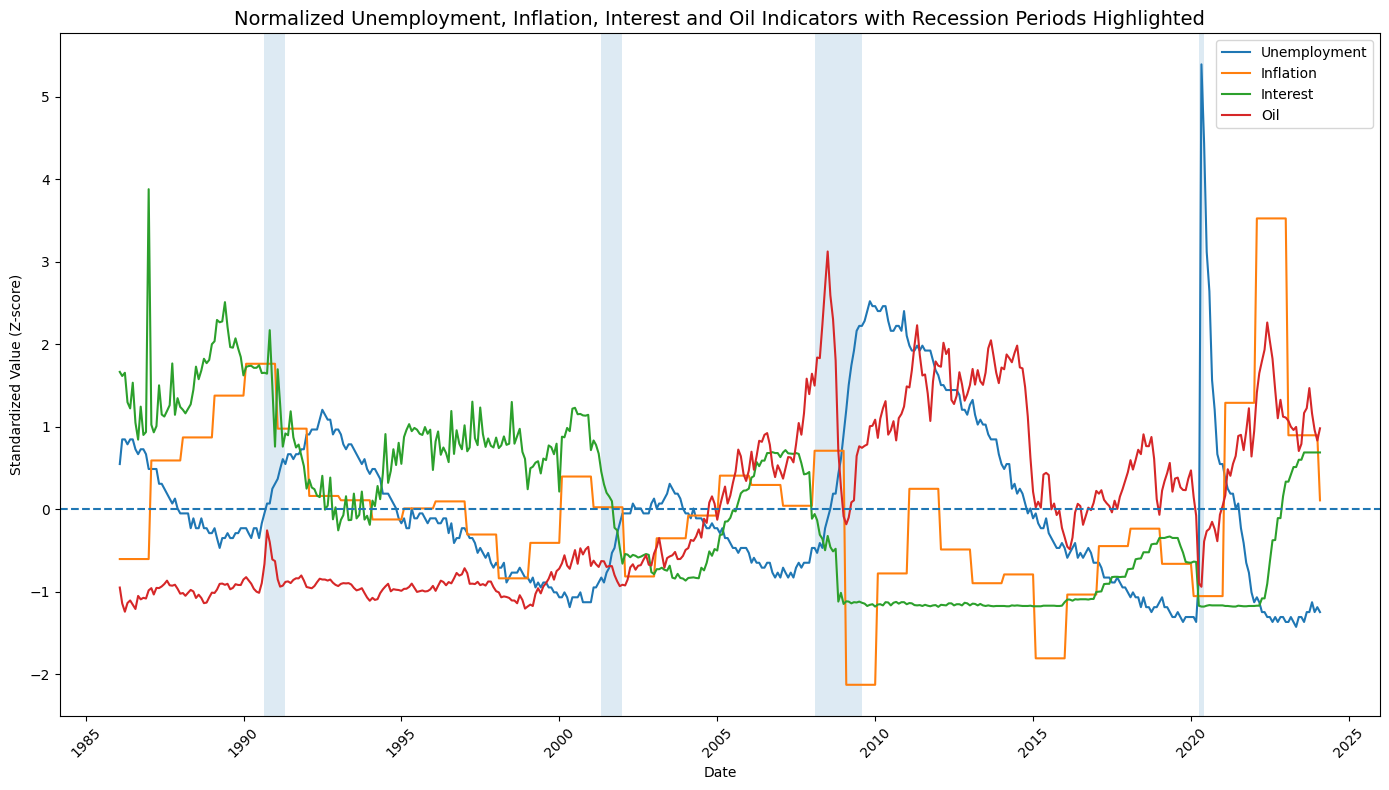

In [101]:
# Line graph comparison for Unemployment, Inflation, and Interest
plt.figure(figsize=(14,8))

plt.plot(economic_normalized.index, economic_normalized["Unemployment"], label="Unemployment")
plt.plot(economic_normalized.index, economic_normalized["Inflation"], label="Inflation")
plt.plot(economic_normalized.index, economic_normalized["Interest"], label="Interest")
plt.plot(economic_normalized.index, economic_normalized["Oil"], label="Oil")

# Highlight recession
start = None
for date in df1.index:
    if df1.loc[date, "Recession"] == 1 and start is None:
        start = date
    elif df1.loc[date, "Recession"] == 0 and start is not None:
        plt.axvspan(start, date, alpha=0.15)
        start = None

if start is not None:
    plt.axvspan(start, df.index[-1], alpha=0.15)

plt.axhline(0, linestyle="--")  # zero line to show average

plt.legend(fontsize=10)
plt.title("Normalized Unemployment, Inflation, Interest and Oil Indicators with Recession Periods Highlighted", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Standardized Value (Z-score)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

During the first 4 economic recession, we have learned that both the Interest rate and Inflation have rised significantly. However, both of those indicators decreased during the last 4 economic recession.

On the other hand, the unemployment indicator was showing downturns followed by a sharp upward trends just before economic recession.

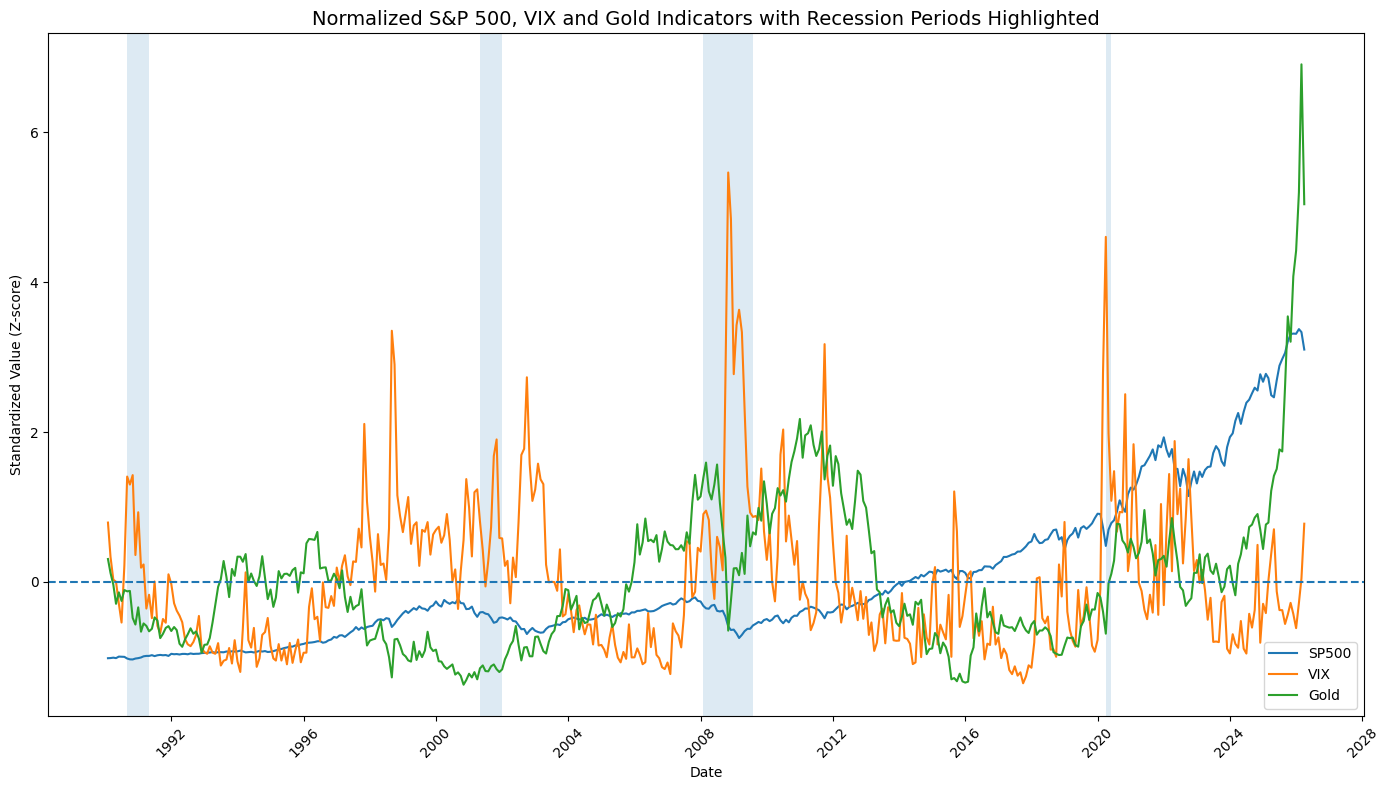

In [102]:
# Line graph comparison for S&P 500, VIX and Gold

plt.figure(figsize=(14,8))

plt.plot(financial_normalized.index, financial_normalized["SP500"], label="SP500")
plt.plot(financial_normalized.index, financial_normalized["VIX"], label="VIX")
plt.plot(financial_normalized.index, financial_normalized["Gold"], label="Gold")

# Highlight recession
start = None
for date in df2.index:
    if df2.loc[date, "Recession"] == 1 and start is None:
        start = date
    elif df2.loc[date, "Recession"] == 0 and start is not None:
        plt.axvspan(start, date, alpha=0.15)
        start = None

if start is not None:
    plt.axvspan(start, df2.index[-1], alpha=0.15)

plt.axhline(0, linestyle="--")  # zero line to show average

plt.legend(fontsize=10)
plt.title("Normalized S&P 500, VIX and Gold Indicators with Recession Periods Highlighted", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Standardized Value (Z-score)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Based on the graph, we have learned that S&P 500 increasing steadily with a slight decrease just before entering economic recession. On the other hand, both the gold and VIX were decreasing for the first two recession, but increasing for the last two recession.

## Data Visualization (Zoom in View)
Now, we are going to create line graphs 2 years before each economic recession. We will then compare the patterns side by side.

At first, we are going with two categories:
1. Unemployment, inflation and interest rate
2. S&P 500, VIX and Gold.

However, in this section, we have decided to create S&P 500 separately because S&P 500 has data starting from 1968. By visualzing S&P 500 data separately, we can learn if S&P 500 has any new information for the first 4 economic recession.

In [103]:
# First get the start and end dates of each recession.
def get_recession_periods(recession_series: pd.Series):
    """
    recession_series: 0/1 Series indexed by datetime (monthly)
    returns list of (start, end) timestamps for each recession
    """
    r = recession_series.fillna(0).astype(int).sort_index()
    starts = r.index[(r.shift(1, fill_value=0) == 0) & (r == 1)]
    ends   = r.index[(r.shift(1, fill_value=0) == 1) & (r == 0)]

    # If series ends while still in recession, close it at last index
    if len(starts) > len(ends):
        ends = ends.append(pd.Index([r.index[-1]]))

    return list(zip(starts, ends))

In [104]:
def plot_zoom_before_recessions(df, indicator_cols,
                                months_before=12, months_after=0,
                                title=None):
    """
    Plots economic indicators around each recession period in a grid layout.

    Each subplot focuses on a single recession, showing a configurable window
    of months before and after the recession. The recession period itself is
    highlighted with a shaded region.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a DatetimeIndex. Must contain a 'Recession' column
        (binary: 1 = recession, 0 = no recession) and all columns listed
        in indicator_cols.
    indicator_cols : list of str
        Column names of the economic indicators to plot on each subplot.
    months_before : int, optional
        Number of months to include before each recession start. Default is 12.
    months_after : int, optional
        Number of months to include after each recession end. Default is 0.
    title : str, optional
        Overall title for the entire figure. If None, no title is added.

    Returns
    -------
    None
        Displays the plot inline. Does not return a value.
    """

    # Extract list of (start, end) tuples for each recession period
    periods = get_recession_periods(df["Recession"])

    # Fix 4 subplots per row; calculate how many rows are needed
    plots_per_row = 4
    nrows = math.ceil(len(periods) / plots_per_row)

    fig, axes = plt.subplots(nrows, plots_per_row,
                             figsize=(20, 4 * nrows))

    # Flatten 2D axes array into 1D for easier indexing
    axes = axes.flatten()

    for i in range(len(periods)):

        start, end = periods[i]
        ax = axes[i]

        # Define the time window to display around each recession
        window_start = start - pd.DateOffset(months=months_before)
        window_end = end + pd.DateOffset(months=months_after)

        # Slice the dataframe to the window
        sub = df.loc[window_start:window_end]

        # Plot each indicator as a separate line on the same subplot
        for col in indicator_cols:
            ax.plot(sub.index, sub[col], label=col)

        ax.legend(fontsize=8)

        # Shade the actual recession period within the window
        ax.axvspan(start, end, alpha=0.2)
        ax.set_title(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")
        ax.tick_params(axis='x', rotation=45)

    # Hide any unused subplots in the grid (when recessions < total grid cells)
    for j in range(len(periods), len(axes)):
        axes[j].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

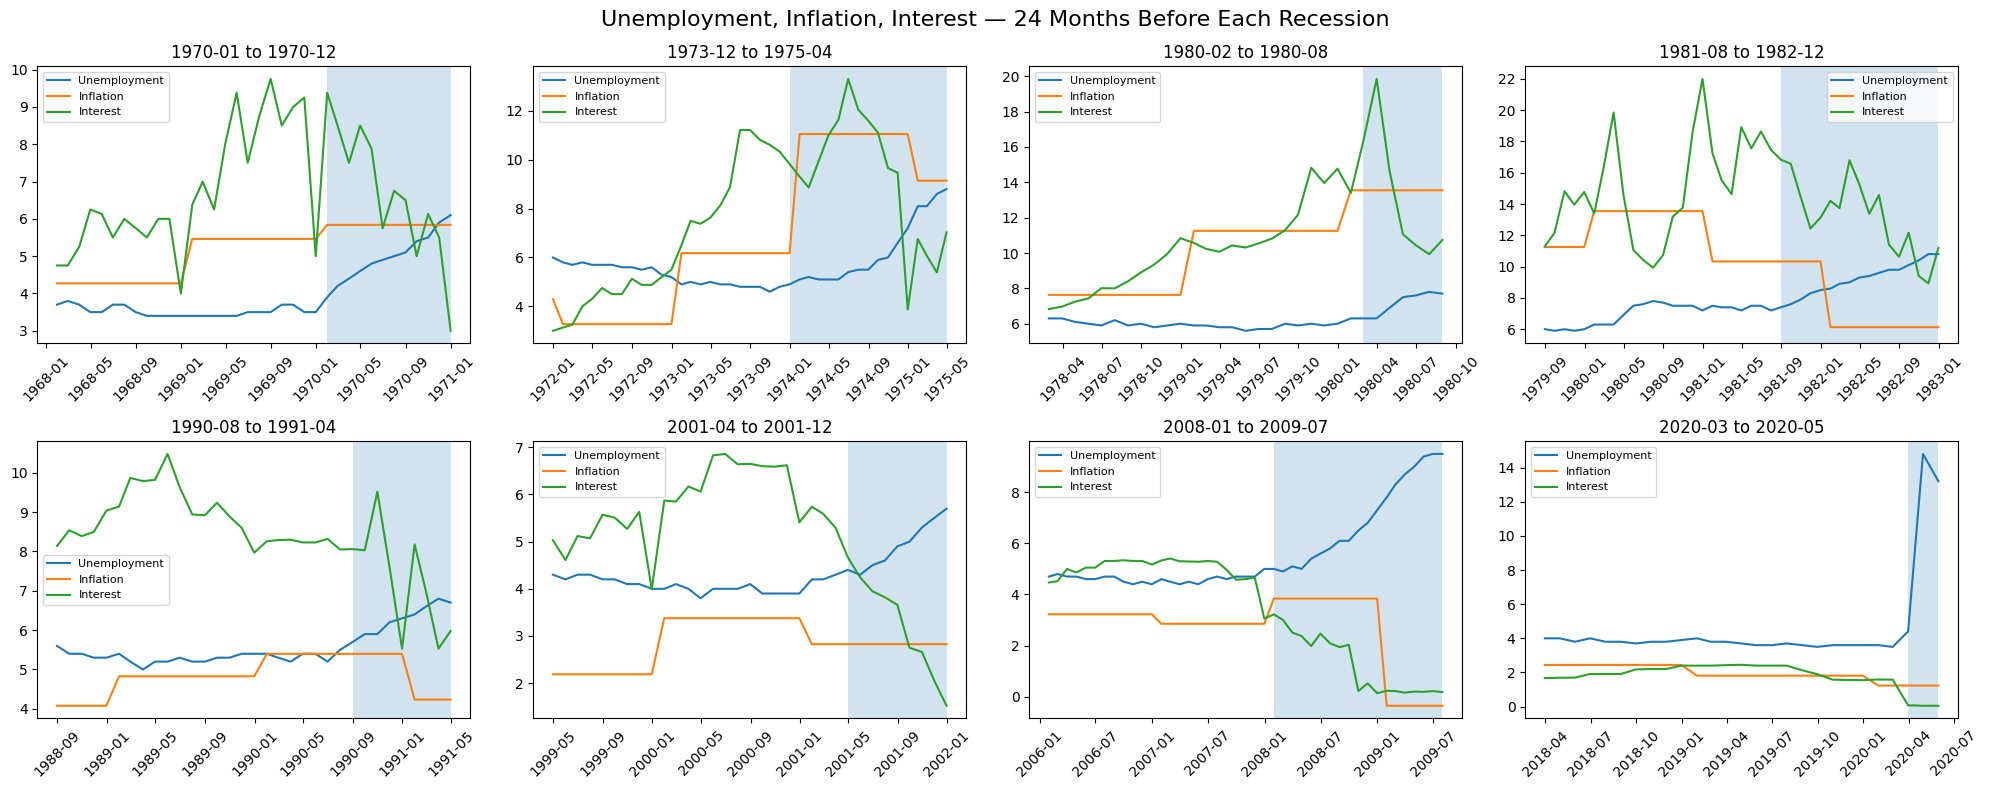

In [105]:
# Plots for Unemployment, Inflation and Interest
plot_zoom_before_recessions(
    economic_df,
    indicator_cols=["Unemployment", "Inflation", "Interest"],
    months_before=24,
    months_after=0,
    title="Unemployment, Inflation, Interest — 24 Months Before Each Recession"
)

##### Oil Reserve Data Graph

In [106]:
# create a oil reserve dataframe
oil_df = oil_monthly.merge(recession,
                            left_index=True,
                            right_index=True,
                            how="left")
oil_df

,Oil,Recession
1986-01-31,18.95,0.0
1986-02-28,13.23,0.0
1986-03-31,10.25,0.0
1986-04-30,13.38,0.0
1986-05-31,14.30,0.0
...,...,...
2025-12-31,57.26,0.0
2026-01-31,64.50,0.0
2026-02-28,66.96,0.0
2026-03-31,102.86,0.0


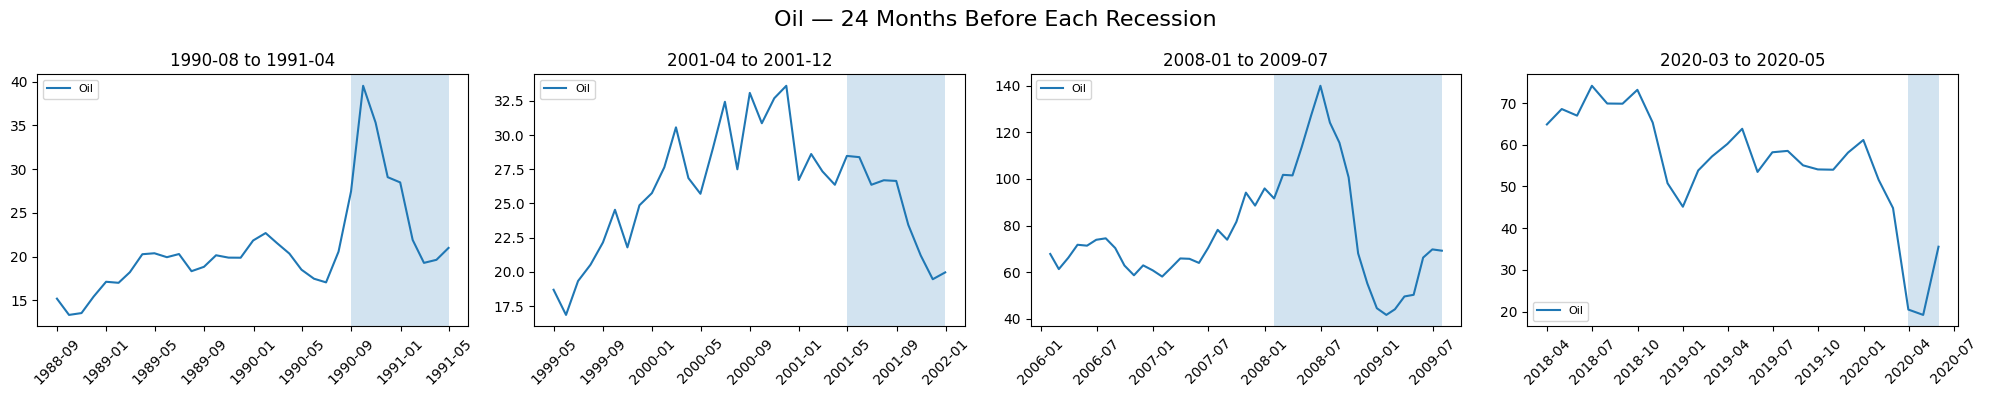

In [107]:
# Plots for oil reserce
plot_zoom_before_recessions(
    oil_df,
    indicator_cols=["Oil"],
    months_before=24,
    months_after=0,
    title="Oil — 24 Months Before Each Recession"
)

#### S&P 500 data

In [108]:
# create a separately dataframe for S&P 500 with data starting from 1968
sp500_df = sp500_monthly.merge(recession,
                            left_index=True,
                            right_index=True,
                            how="left")
sp500_df = sp500_df.rename(columns={
    '^GSPC': 'SP500',
})
sp500_df

,SP500,Recession
Date,,
1968-01-31,92.239998,0.0
1968-02-29,89.360001,0.0
1968-03-31,90.199997,0.0
1968-04-30,97.459999,0.0
1968-05-31,98.680000,0.0
...,...,...
2025-12-31,6845.500000,0.0
2026-01-31,6939.029785,0.0
2026-02-28,6878.879883,0.0


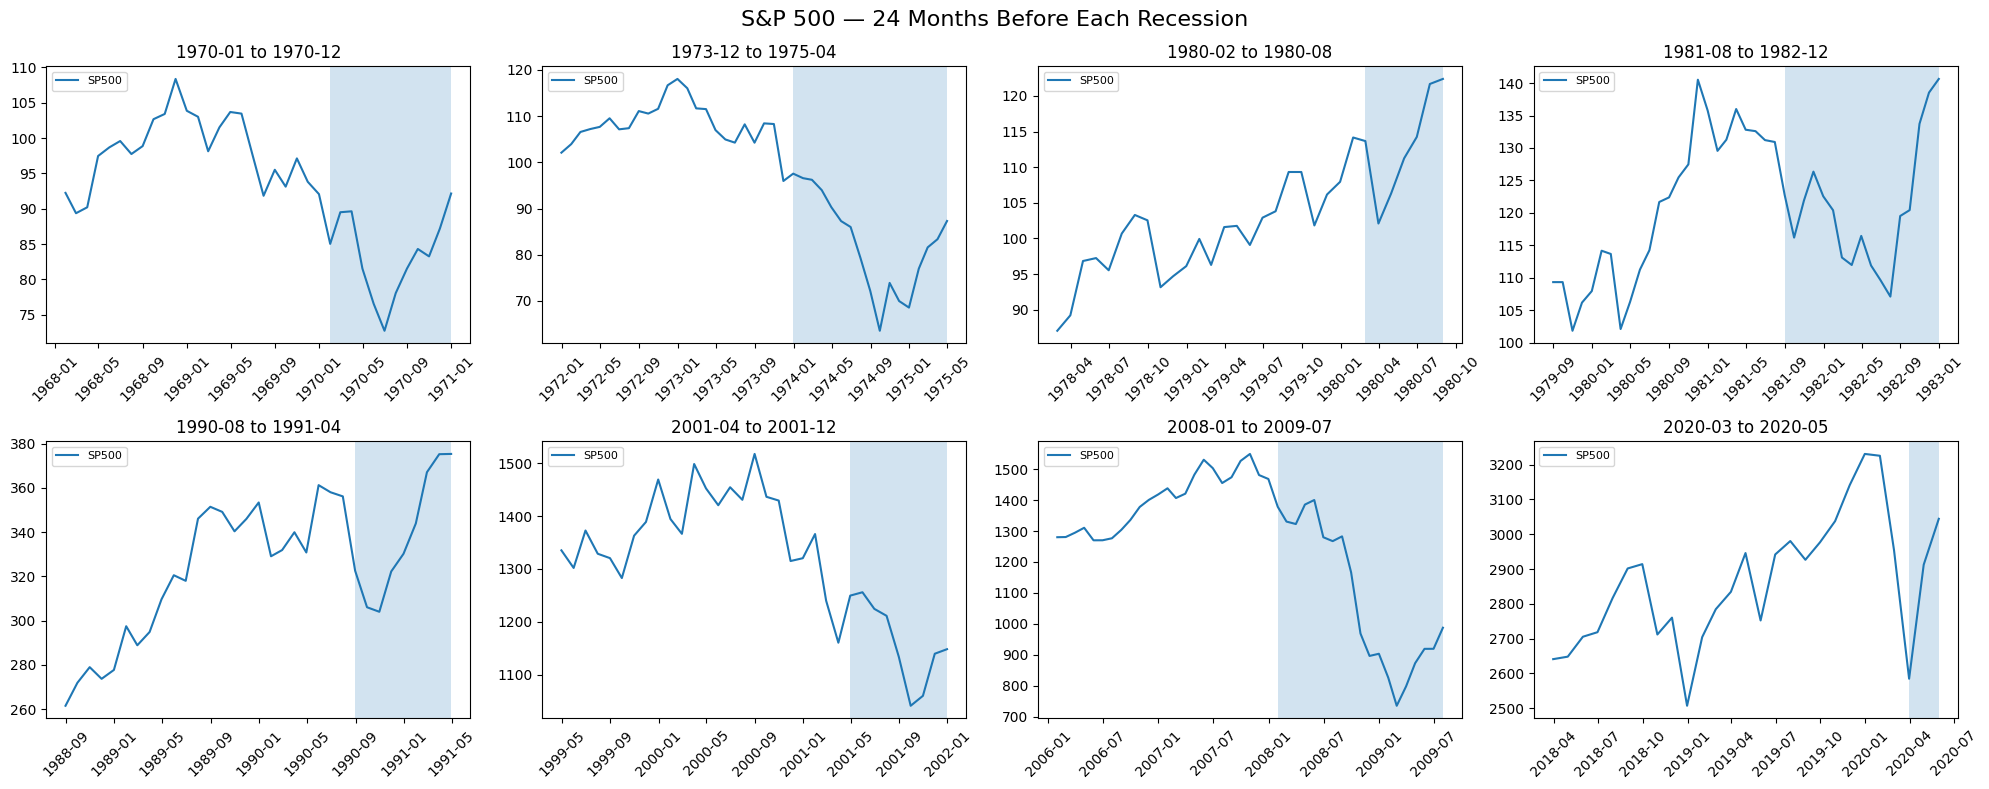

In [109]:
# Plots for S&P 500
plot_zoom_before_recessions(
    sp500_df,
    indicator_cols=["SP500"],
    months_before=24,
    months_after=0,
    title="S&P 500 — 24 Months Before Each Recession"
)

Based on the graphs, we have learned that S&P 500 was going down a few months before each recession.

In [110]:
# Combine VIX and Gold data to create a new dataframe
vix_gold = pd.concat([
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
vix_gold = vix_gold.rename(columns={
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

In [111]:
# Dataframe for VIX and Gold
vix_gold_df = vix_gold.merge(recession,
                            left_index=True,
                            right_index=True,
                            how="left")
vix_gold_df

,VIX,Gold,Recession
Date,,,
1990-01-31,25.360001,130.279999,0.0
1990-02-28,21.990000,120.720001,0.0
1990-03-31,19.730000,112.709999,0.0
1990-04-30,19.520000,99.470001,0.0
1990-05-31,17.370001,107.370003,0.0
...,...,...,...
2025-12-31,14.950000,342.279999,0.0
2026-01-31,17.440001,382.329987,0.0
2026-02-28,19.860001,470.369995,0.0


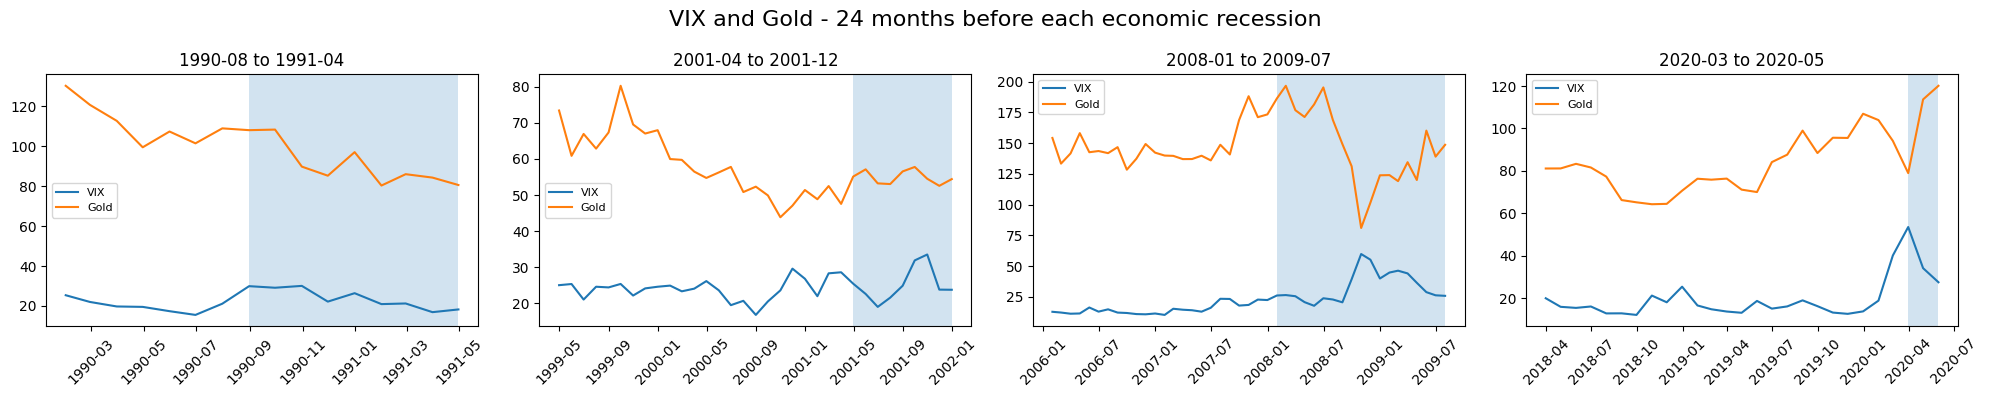

In [112]:
# Plots for VIX and Gold
plot_zoom_before_recessions(
    vix_gold_df,
    indicator_cols=["VIX", "Gold"],
    months_before=24,
    months_after=0,
    title = "VIX and Gold - 24 months before each economic recession"
)

## Correlations between economic indicators

### 1. Economic: Unemployment, Inflation, Interest

In [113]:
economic_corr = economic_df[["Unemployment","Inflation","Interest", "Oil"]].corr()

print(economic_corr)

              Unemployment  Inflation  Interest       Oil
Unemployment      1.000000   0.046060  0.059015  0.080652
Inflation         0.046060   1.000000  0.690763  0.036430
Interest          0.059015   0.690763  1.000000 -0.565865
Oil               0.080652   0.036430 -0.565865  1.000000


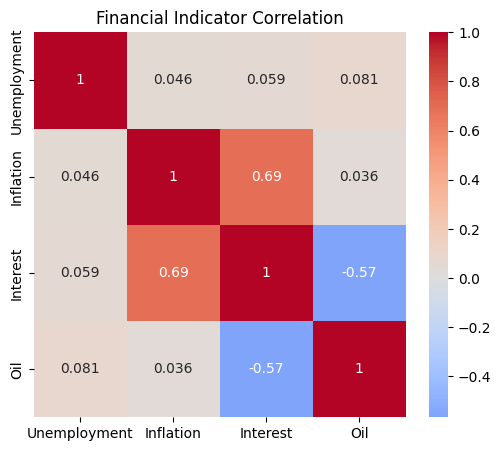

In [114]:
plt.figure(figsize=(6,5))

sns.heatmap(
    economic_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Financial Indicator Correlation")
plt.show()

### 2. Financial: SP500, VIX, Gold

In [115]:
financial_corr = financial_df[["SP500","VIX","Gold"]].corr()

print(financial_corr)

          SP500       VIX      Gold
SP500  1.000000 -0.060288  0.424917
VIX   -0.060288  1.000000 -0.014245
Gold   0.424917 -0.014245  1.000000


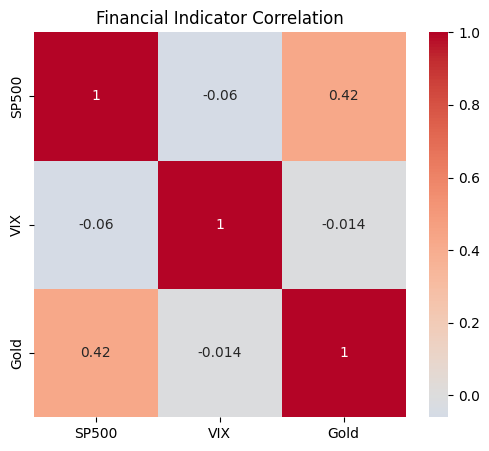

In [116]:
plt.figure(figsize=(6,5))

sns.heatmap(
    financial_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Financial Indicator Correlation")
plt.show()

### Correlation for All Variables

In [117]:
combined_df = pd.concat([
    financial_df[["SP500","VIX","Gold"]],
    economic_df[["Unemployment","Inflation","Interest", "Oil"]]
], axis=1)

In [118]:
combined_corr = combined_df.corr()

print(combined_corr)

                 SP500       VIX      Gold  Unemployment  Inflation  Interest  \
SP500         1.000000 -0.060288  0.424917     -0.374804  -0.327042 -0.453066   
VIX          -0.060288  1.000000 -0.014245      0.173981  -0.001309 -0.107230   
Gold          0.424917 -0.014245  1.000000      0.272360   0.125762 -0.107379   
Unemployment -0.374804  0.173981  0.272360      1.000000   0.046060  0.059015   
Inflation    -0.327042 -0.001309  0.125762      0.046060   1.000000  0.690763   
Interest     -0.453066 -0.107230 -0.107379      0.059015   0.690763  1.000000   
Oil           0.513023 -0.046154  0.505310      0.080652   0.036430 -0.565865   

                   Oil  
SP500         0.513023  
VIX          -0.046154  
Gold          0.505310  
Unemployment  0.080652  
Inflation     0.036430  
Interest     -0.565865  
Oil           1.000000  


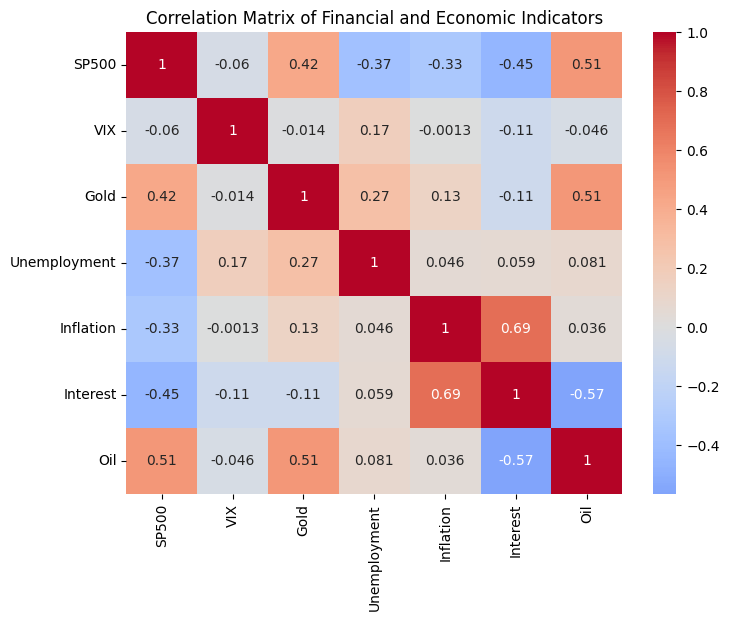

In [119]:
plt.figure(figsize=(8,6))

sns.heatmap(
    combined_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial and Economic Indicators")

plt.show()

Based on the heatmap, we observe that **inflation and interest rates have a strong positive correlation (0.69)**. This is because central banks raise interest rates to control rising inflation. When inflation increases, the Federal Reserve typically increases rates to reduce spending and slow price growth.

The **S&P 500 has a negative correlation with interest rates (-0.46)**. Higher interest rates increase borrowing costs for companies and reduce future earnings expectations, which can lower stock prices.

The **S&P 500 also has a negative correlation with unemployment (-0.37)**. When unemployment rises, consumer spending and company profits often decline, which negatively affects stock performance.

**Gold shows a moderate positive correlation with the S&P 500 (0.41)**, suggesting that in some periods both may rise due to broader economic growth or liquidity conditions.

Overall, while the correlations are moderate rather than strong, they reflect logical economic relationships between monetary policy, economic conditions, and financial markets.

## Indicator Importance
Now, we are going to explore the importance of each economic indicators, 3 months, 6 months, 1 year and 2 years before recession.

In [120]:
def compute_recession_change(df, indicators, recession_col="Recession", months_before=12):
    """
    Computes the percentage change of economic indicators in the period
    leading up to each recession start.

    For each recession, this function looks back a fixed number of months
    before the recession begins and calculates how much each indicator
    changed from that point to the recession start date.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a DatetimeIndex. Must contain a binary recession
        column and all columns listed in indicators.
    indicators : list of str
        Column names of the economic indicators to measure.
    recession_col : str, optional
        Name of the column indicating recession periods (1 = recession,
        0 = no recession). Default is 'Recession'.
    months_before : int, optional
        How many months before each recession start to use as the
        baseline value. Default is 12.

    Returns
    -------
    pd.DataFrame
        A DataFrame where each row is a recession year and each column
        is an indicator, with values representing the percentage change
        from the baseline month to the recession start.
    """

    # Identify recession start dates: rows where recession switches from 0 to 1
    recession_start = df[(df[recession_col] == 1) & (df[recession_col].shift(1) == 0)].index

    results = {}

    for start in recession_start:

        # Slice all rows up to and including the recession start date
        window = df.loc[:start, indicators]

        # Skip if there is not enough historical data before this recession
        if len(window) > months_before:

            # Baseline value: the row exactly `months_before` months ago
            before = window.iloc[-(months_before + 1)]

            # Value at the moment the recession begins
            start_val = window.iloc[-1]

            # Percentage change from baseline to recession start
            pct_change = (start_val - before) / before * 100

            # Store result keyed by the recession's year
            results[start.year] = pct_change

    # Combine all recession results into a single DataFrame (rows = recession years)
    return pd.DataFrame(results).T

### 1. Economic: Unemployment, Inflation, Interest, S&P500 (1968 to 2024)

In [121]:
# Dataframe for all 4 economic indicators
df1968 = data1.merge(sp500_df,
                            left_index=True,
                            right_index=True,
                            how="left")
df1968

,Unemployment,Inflation,Interest,Oil,SP500,Recession
1968-01-31,3.7,4.271796,4.75,NaN,92.239998,0.0
1968-02-29,3.8,4.271796,4.75,NaN,89.360001,0.0
1968-03-31,3.7,4.271796,5.25,NaN,90.199997,0.0
1968-04-30,3.5,4.271796,6.25,NaN,97.459999,0.0
1968-05-31,3.5,4.271796,6.13,NaN,98.680000,0.0
...,...,...,...,...,...,...
2025-12-31,4.4,NaN,3.64,57.26,6845.500000,0.0
2026-01-31,4.3,NaN,3.64,64.50,6939.029785,0.0
2026-02-28,4.4,NaN,3.64,66.96,6878.879883,0.0
2026-03-31,4.3,NaN,3.64,102.86,6528.520020,0.0


In [122]:
# Generate Results for All Windows
windows = [1, 3, 6, 12, 24]

heatmaps = {}

for w in windows:
    heatmaps[w] = compute_recession_change(
        df1968,
        indicators=["Unemployment", "Inflation", "Interest", "SP500"],
        months_before=w
    )

all_values = pd.concat(heatmaps.values())

vmin = all_values.min().min()
vmax = all_values.max().max()

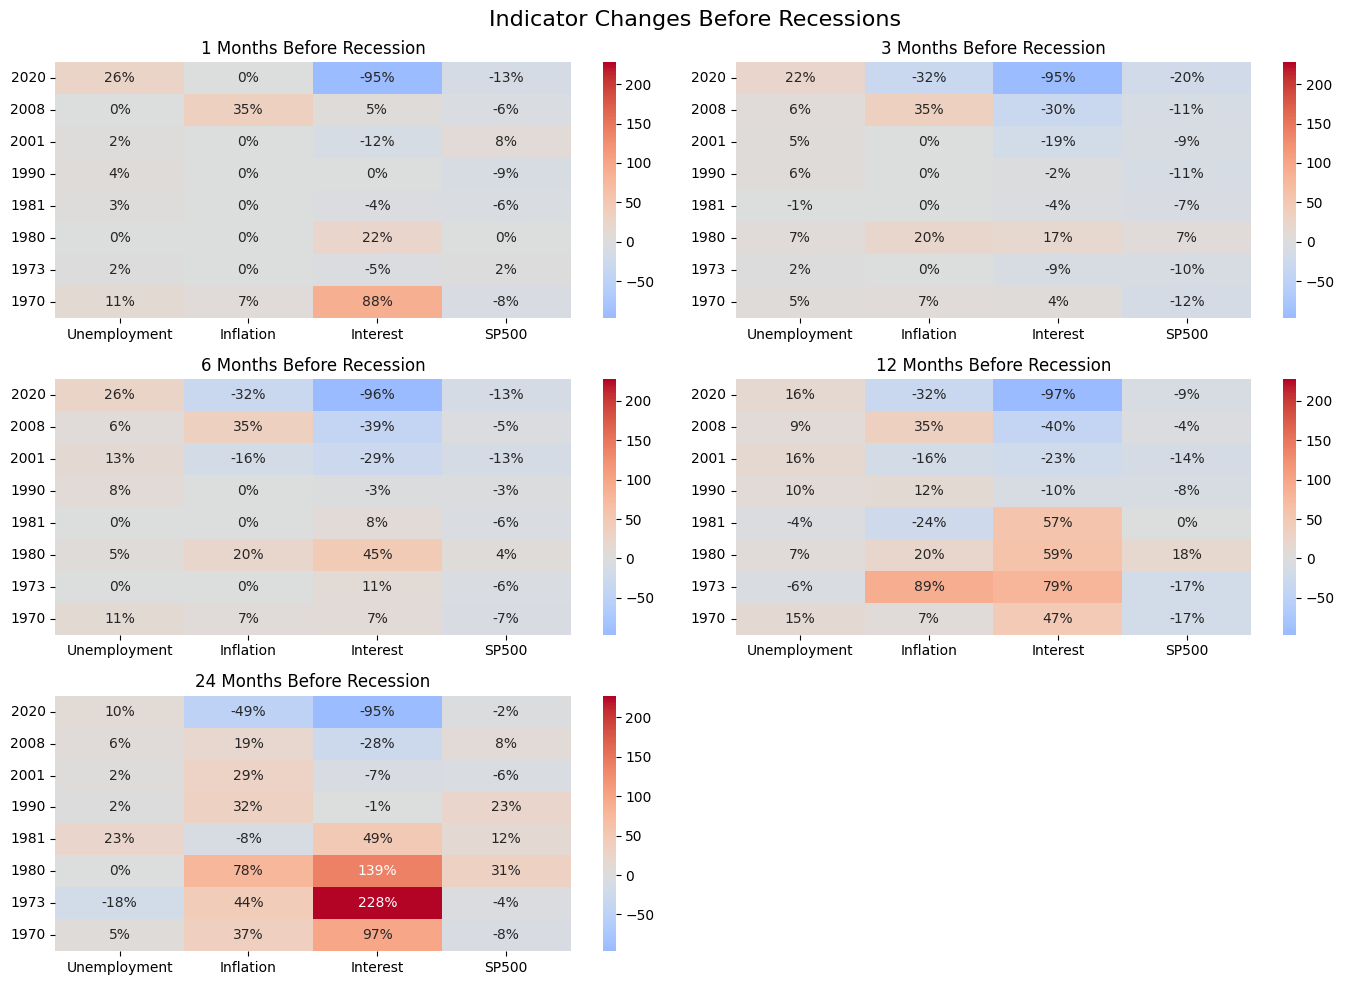

In [123]:
fig, axes = plt.subplots(3,2, figsize=(14,10))
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps[w].iloc[::-1]
    annot_data = data.round(0).astype(int).astype(str) + "%"

    sns.heatmap(
        data,
        annot=annot_data,
        fmt="",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"{w} Months Before Recession")

plt.suptitle("Indicator Changes Before Recessions", fontsize=16)

axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

#### Bubble Plot

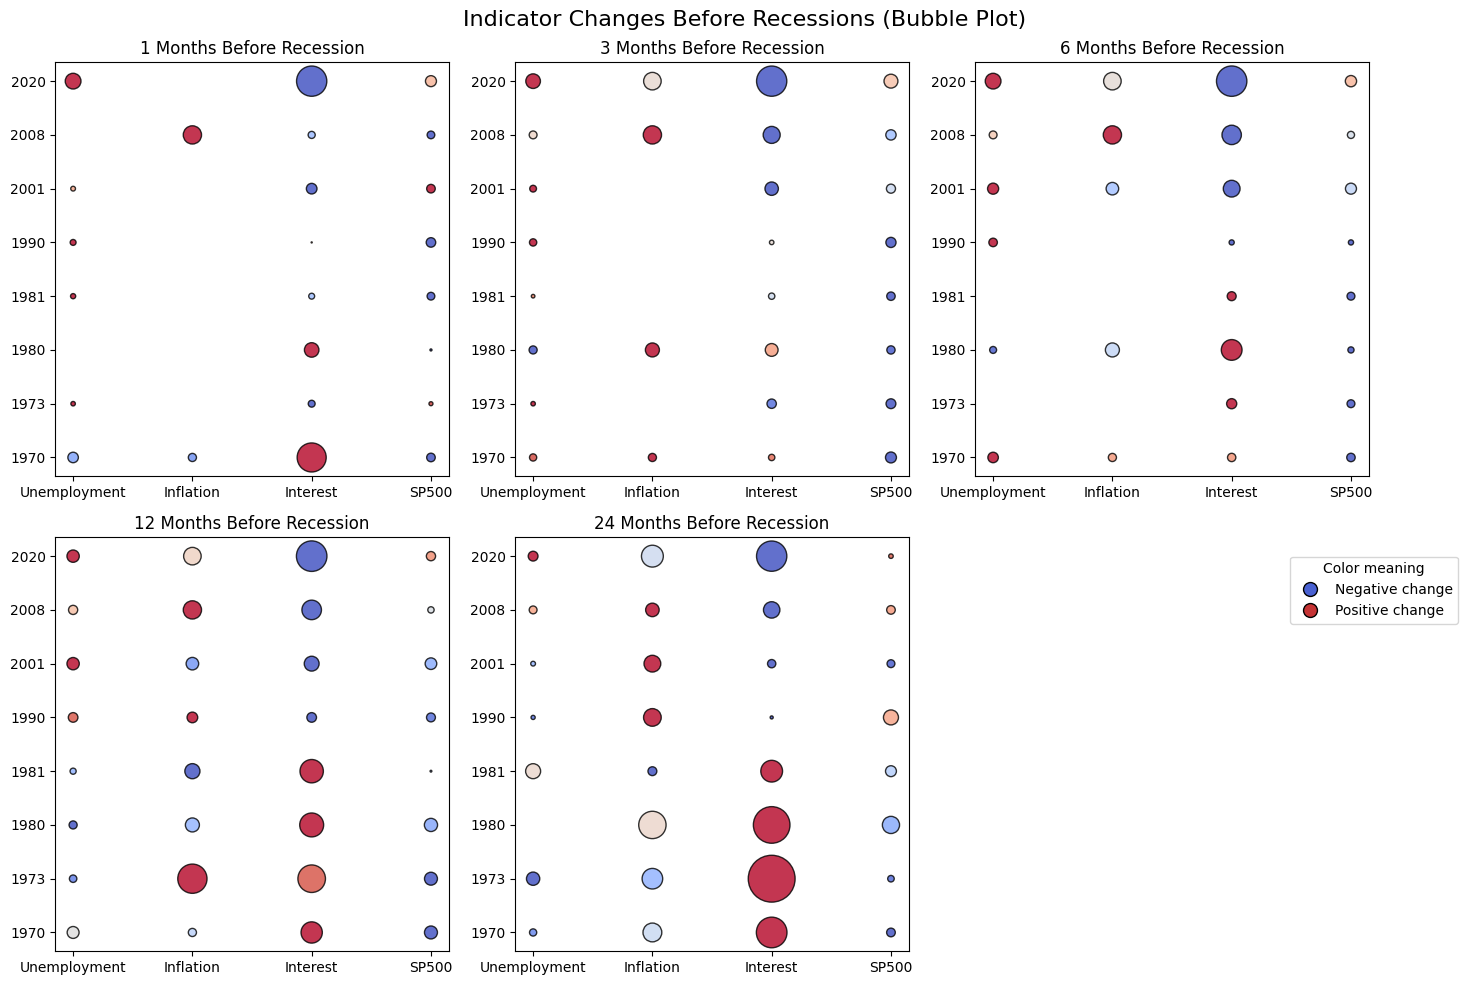

In [127]:
from matplotlib.lines import Line2D

windows = [1, 3, 6, 12, 24]

# --- Dynamic subplot layout ---
n = len(windows)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, w in enumerate(windows):

    df_change = compute_recession_change(
        df1968,
        indicators=["Unemployment", "Inflation", "Interest", "SP500"],
        months_before=w
    )

    x = np.arange(len(df_change.columns))

    for j, recession in enumerate(df_change.index):
        values = df_change.loc[recession]

        axes[i].scatter(
            x,
            [j] * len(x),
            s=np.abs(values) * 5,   # bubble size = magnitude
            c=values,
            cmap="coolwarm",        # keep original color range/behavior
            alpha=0.8,
            edgecolor="black"
        )

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_change.columns)
    axes[i].set_yticks(range(len(df_change.index)))
    axes[i].set_yticklabels(df_change.index)
    axes[i].set_title(f"{w} Months Before Recession")

# Hide unused subplot(s)
for k in range(n, len(axes)):
    axes[k].axis("off")

# --- Direction legend only ---
cmap = plt.cm.coolwarm
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Negative change',
        markerfacecolor=cmap(0.05),
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Positive change',
        markerfacecolor=cmap(0.95),
        markeredgecolor='black',
        markersize=10
    )
]

fig.legend(
    handles=legend_elements,
    loc='center right',
    bbox_to_anchor=(0.98, 0.4),
    frameon=True,
    title='Color meaning'
)

plt.suptitle("Indicator Changes Before Recessions (Bubble Plot)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.93, 1])  # leave room on right for legend
plt.show()

This suggest that:
- Unemployment: rises after recession begins, not before, not a strong indicator
- Inflation: very mixed pattern
- Interest Rate: behave differently because they reflect monetary policy responses
- S&P 500: shows negative 3 to 6 months before, but some shows positive pattern 1 year and 2 years before recession.

So the pattern depends on the cause of the recession.

### 2. S&P500, VIX, Gold, Oil (1990 to 2024)

In [124]:
data2 = data2.loc["1986-01-01":]
oil_df = oil_df.loc["1986-01-01":]

df1986 = data2.merge(oil_df,
                     left_index=True,
                     right_index=True,
                     how="left")

df1986

,SP500,VIX,Gold,Oil,Recession
Date,,,,,
1986-01-31,211.779999,NaN,NaN,18.95,0.0
1986-02-28,226.919998,NaN,NaN,13.23,0.0
1986-03-31,238.899994,NaN,NaN,10.25,0.0
1986-04-30,235.520004,NaN,NaN,13.38,0.0
1986-05-31,247.350006,NaN,NaN,14.30,0.0
...,...,...,...,...,...
2025-12-31,6845.500000,14.950000,342.279999,57.26,0.0
2026-01-31,6939.029785,17.440001,382.329987,64.50,0.0
2026-02-28,6878.879883,19.860001,470.369995,66.96,0.0


In [142]:
# Generate Results for All Windows
windows = [1, 3, 6, 12, 24]

heatmaps = {}

for w in windows:
    heatmaps[w] = compute_recession_change(
        df1986,
        indicators=["SP500", "VIX", "Gold", "Oil"],
        months_before=w
    )

all_values = pd.concat(heatmaps.values())

vmin = all_values.min().min()
vmax = all_values.max().max()

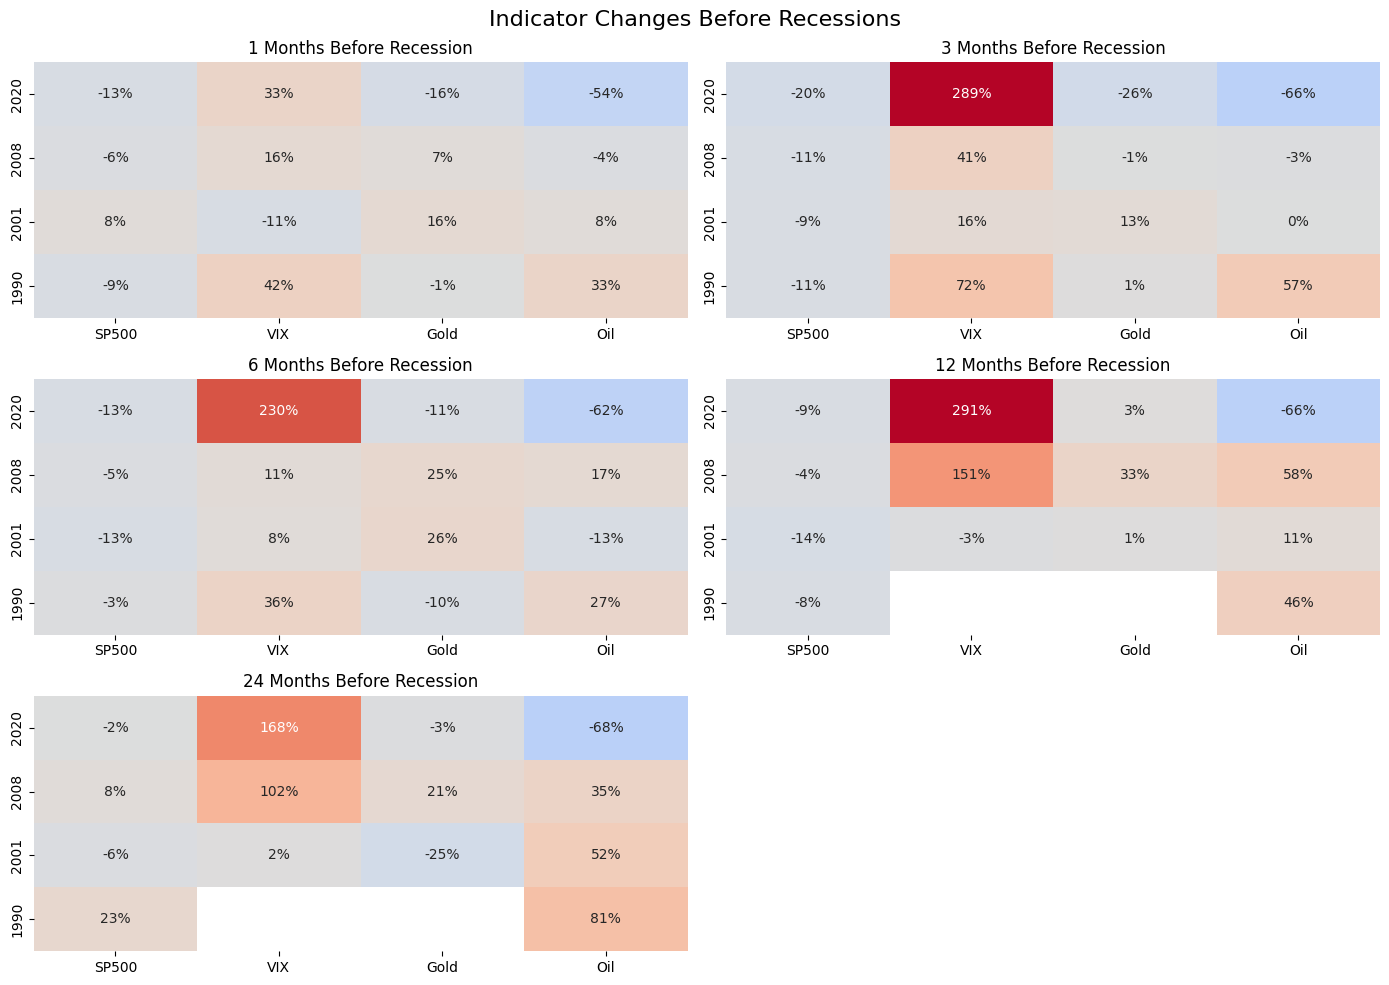

In [126]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps[w].iloc[::-1]  # <-- reverse rows (latest on top)

    # Create annotation (handle NaN properly)
    annot_data = data.copy()
    annot_data = annot_data.round(0)

    annot_data = annot_data.astype("Int64").astype(str) + "%"
    annot_data = annot_data.replace("<NA>%", "")  # remove NaN labels

    sns.heatmap(
        data,
        annot=annot_data,
        fmt="",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        center=0,
        ax=axes[i],
        cbar=False  # optional: cleaner look (since repeated 5 times)
    )

    axes[i].set_title(f"{w} Months Before Recession")

plt.suptitle("Indicator Changes Before Recessions", fontsize=16)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

##### Bubble Plot

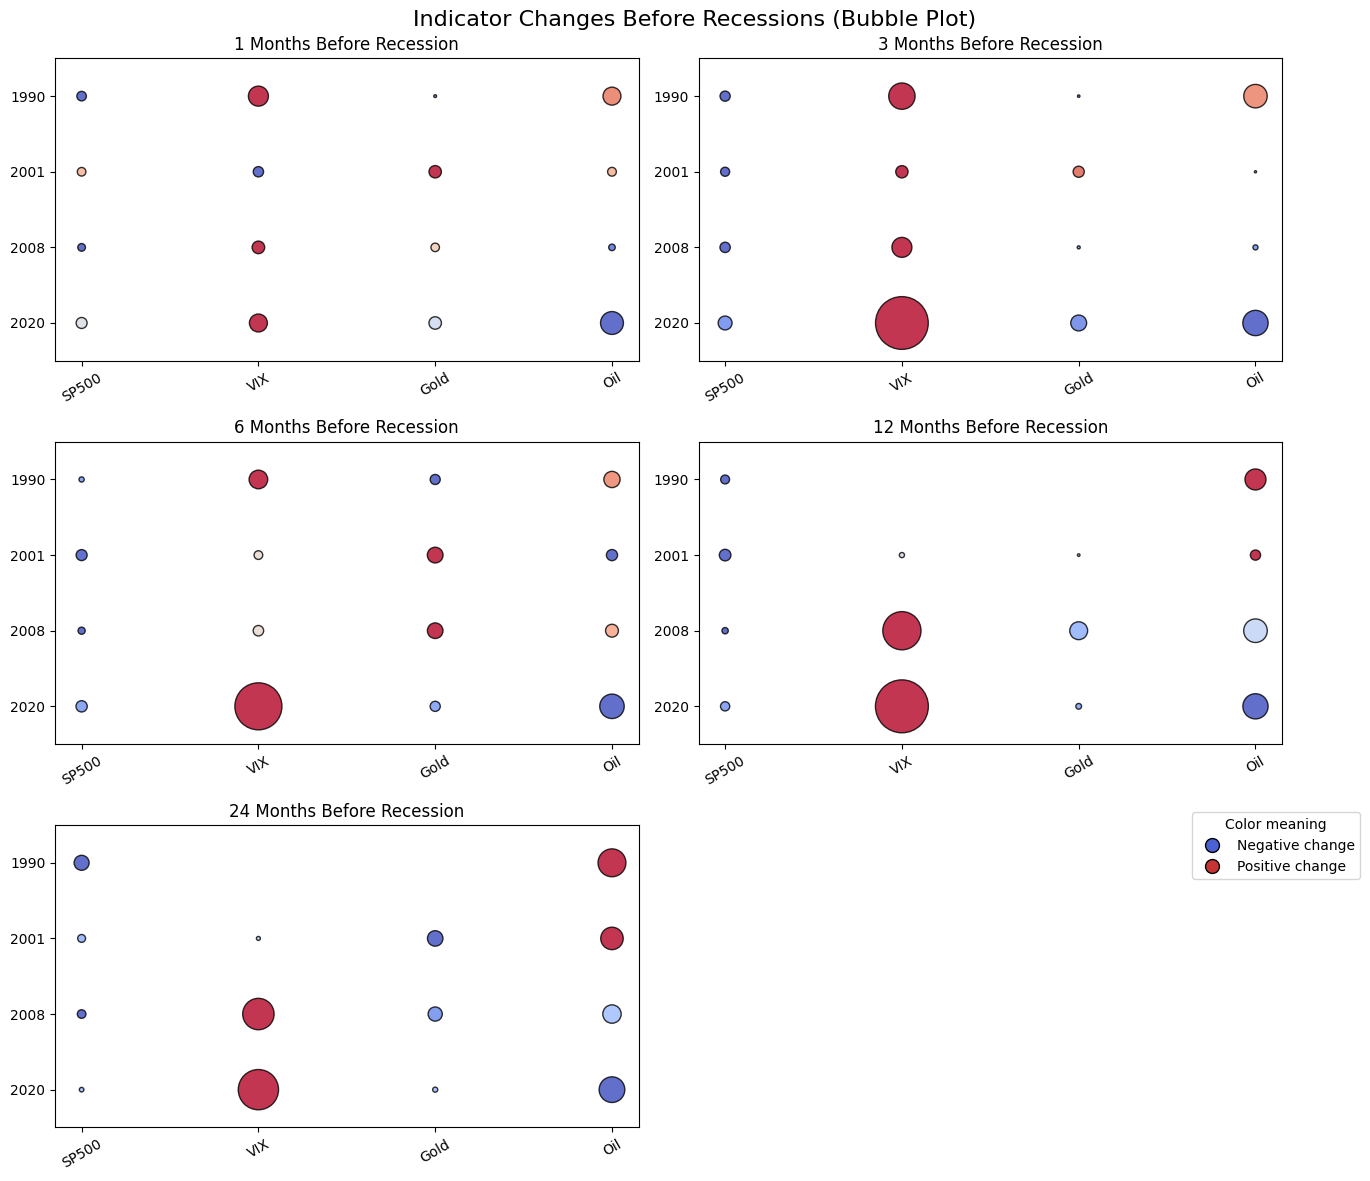

In [145]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))  # increased height
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps[w].iloc[::-1]  # reverse rows (latest on top)
    x = np.arange(len(data.columns))

    for j, recession in enumerate(data.index):
        values = data.loc[recession]
        mask = values.notna()

        axes[i].scatter(
            x[mask],
            [j] * sum(mask),
            s=np.abs(values[mask]) * 5,
            c=values[mask],
            cmap="coolwarm",
            alpha=0.8,
            edgecolor="black"
        )

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(data.columns, rotation=30)
    axes[i].set_yticks(range(len(data.index)))
    axes[i].set_yticklabels(data.index)

    # Add extra vertical room so bubbles at top/bottom are fully visible
    axes[i].set_ylim(-0.5, len(data.index) - 0.5)

    axes[i].set_title(f"{w} Months Before Recession")

# Hide empty subplot
axes[-1].axis("off")

# --- Add legend (moved lower and farther right) ---
cmap = plt.cm.coolwarm
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Negative change',
        markerfacecolor=cmap(0.05),
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Positive change',
        markerfacecolor=cmap(0.95),
        markeredgecolor='black',
        markersize=10
    )
]

fig.legend(
    handles=legend_elements,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.25),
    title='Color meaning',
    frameon=True
)

plt.suptitle("Indicator Changes Before Recessions (Bubble Plot)", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.93, 1])  # leave room on right for legend

plt.show()

3. S&P500, VIX, Gold (1990 to 2024)

In [128]:
# Generate Results for All Windows
windows = [1, 3, 6, 12, 24]

heatmaps = {}

for w in windows:
    heatmaps[w] = compute_recession_change(
        financial_df.dropna(),
        indicators=["SP500","VIX","Gold"],
        months_before=w
    )

all_values = pd.concat(heatmaps.values())

vmin = all_values.min().min()
vmax = all_values.max().max()

#### Heatmap

In [129]:
# Note that 1990 recession start at 1990 August, and our financial data start at 1990 January.
# This is why for the 12 and 24 month before recession incdicator change is missing 1990 recession
print(financial_df.index.min())
recession_start = financial_df[
    (financial_df["Recession"] == 1) &
    (financial_df["Recession"].shift(1) == 0)
].index

print(recession_start)

1968-01-31 00:00:00
DatetimeIndex(['1970-01-31', '1973-12-31', '1980-02-29', '1981-08-31',
               '1990-08-31', '2001-04-30', '2008-01-31', '2020-03-31'],
              dtype='datetime64[ns]', name='Date', freq=None)


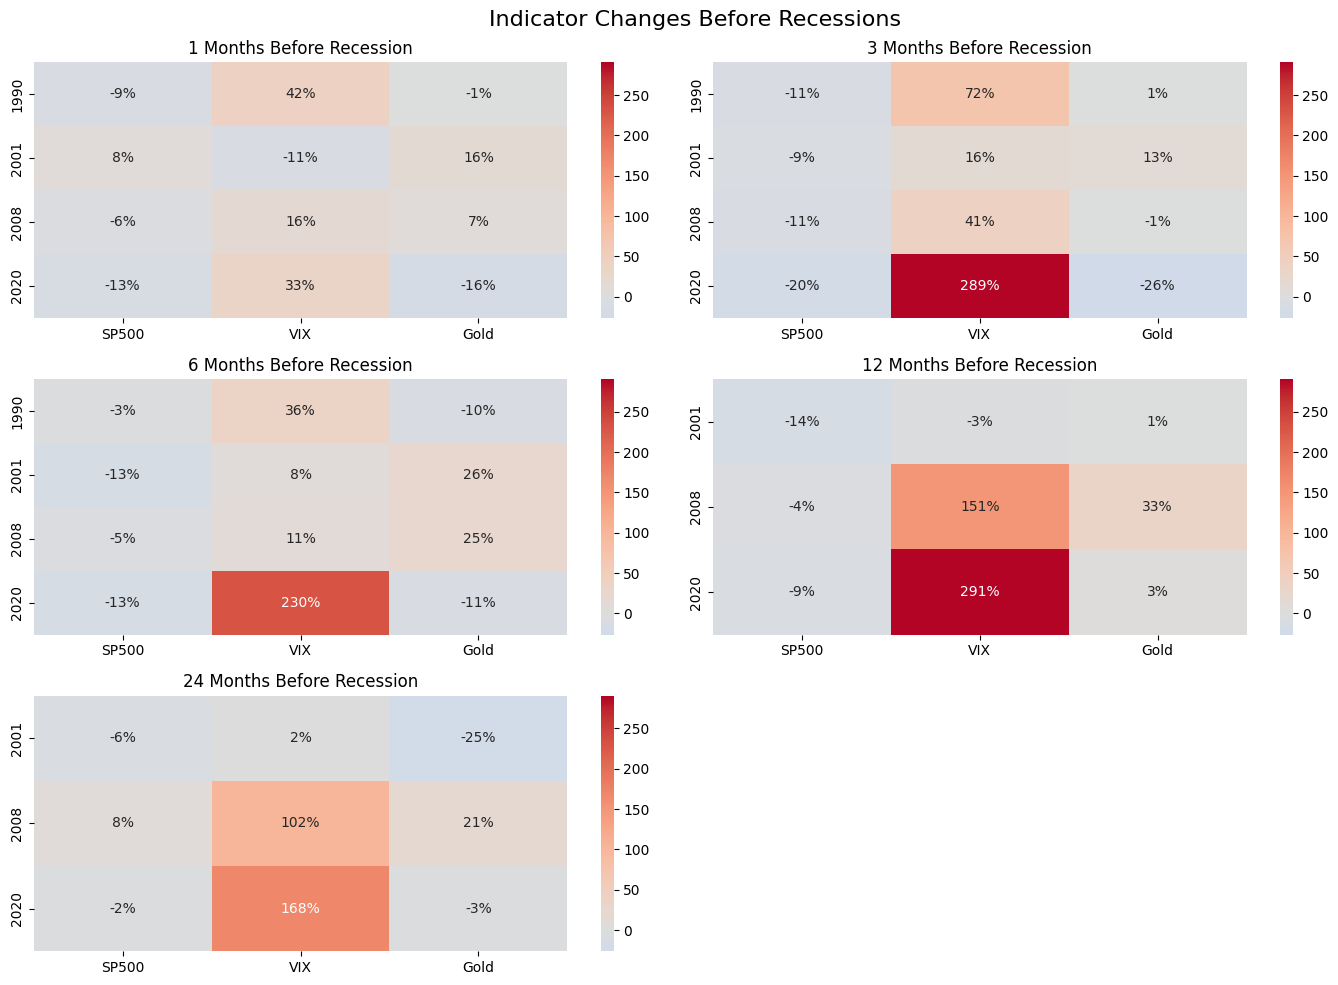

In [130]:
fig, axes = plt.subplots(3,2, figsize=(14,10))
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps[w]
    annot_data = data.round(0).astype(int).astype(str) + "%"

    sns.heatmap(
        data,
        annot=annot_data,
        fmt="",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"{w} Months Before Recession")

plt.suptitle("Indicator Changes Before Recessions", fontsize=16)

axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

Note that 1990 recession start at 1990 August, and our financial data start at 1990 January, which is why the 1990 recession is missing in the 12 and 24 month heat maps.

Based on the heatmap,
  - S&P500: gradually decrease before recessions
  - VIX: spikes dramatically as recession approaches
  - Gold: not consistent.

#### Bubble Plot

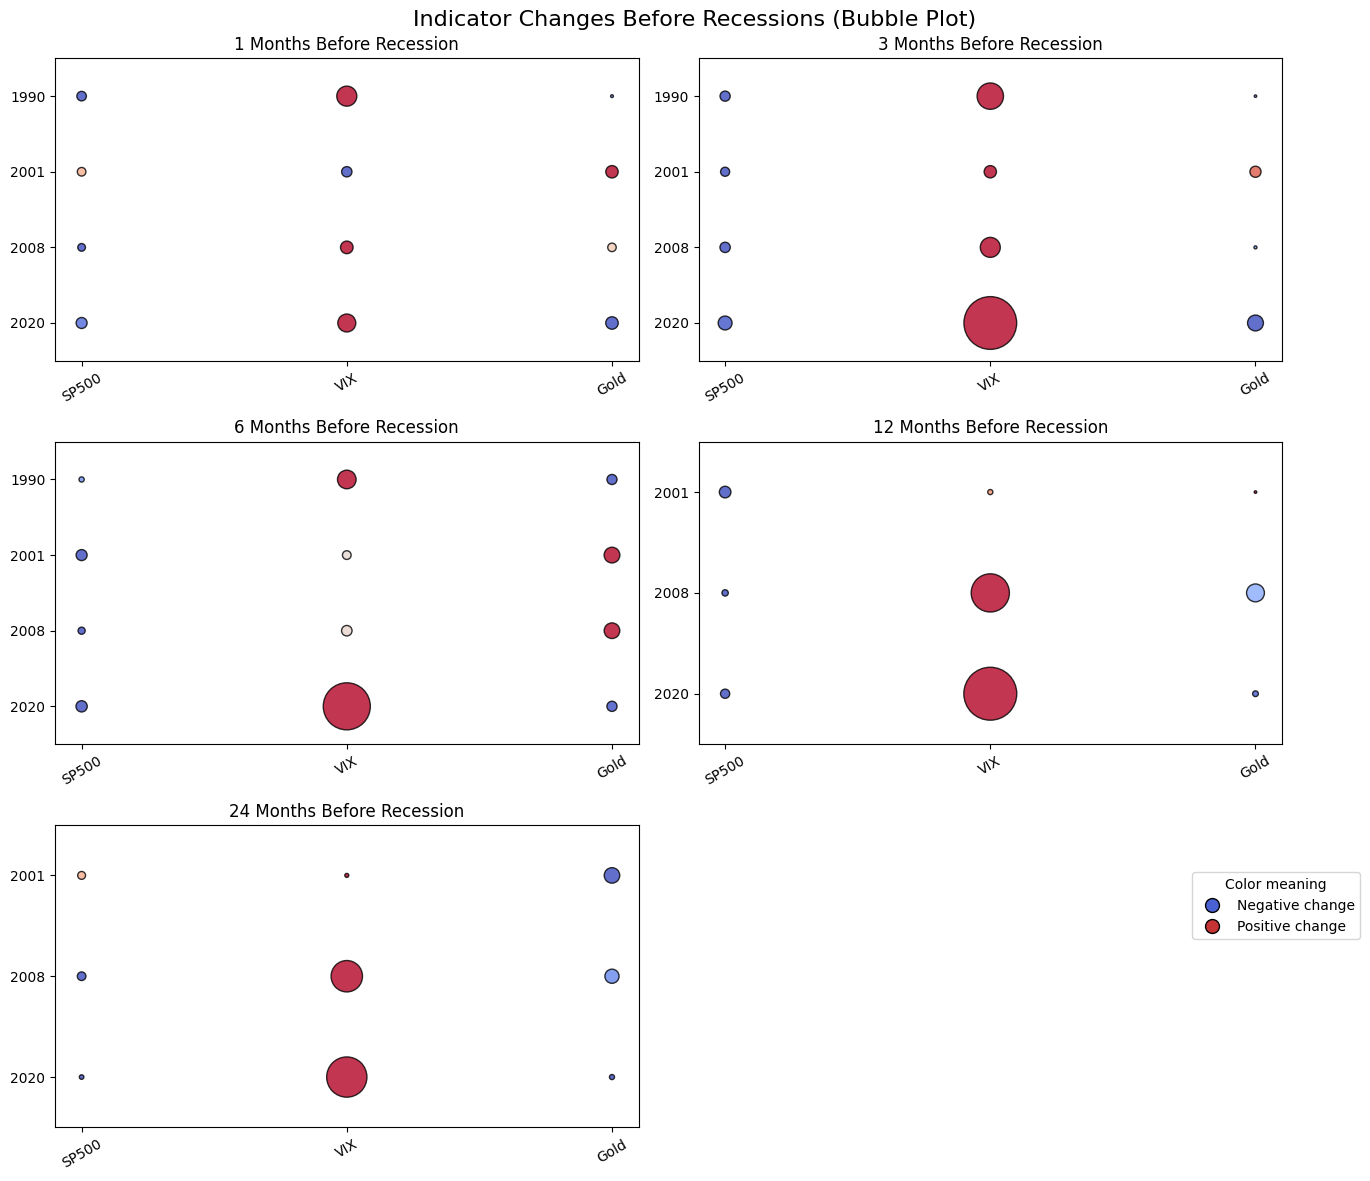

In [131]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))  # increased height
axes = axes.flatten()

for i, w in enumerate(windows):
    data = heatmaps[w].iloc[::-1]  # reverse rows (latest on top)
    x = np.arange(len(data.columns))

    for j, recession in enumerate(data.index):
        values = data.loc[recession]
        mask = values.notna()

        axes[i].scatter(
            x[mask],
            [j] * sum(mask),
            s=np.abs(values[mask]) * 5,
            c=values[mask],
            cmap="coolwarm",
            alpha=0.8,
            edgecolor="black"
        )

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(data.columns, rotation=30)
    axes[i].set_yticks(range(len(data.index)))
    axes[i].set_yticklabels(data.index)

    # Add extra vertical room so bubbles at top/bottom are fully visible
    axes[i].set_ylim(-0.5, len(data.index) - 0.5)

    axes[i].set_title(f"{w} Months Before Recession")

# Hide empty subplot
axes[-1].axis("off")

# --- Add legend (moved lower and farther right) ---
cmap = plt.cm.coolwarm
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Negative change',
        markerfacecolor=cmap(0.05),
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Positive change',
        markerfacecolor=cmap(0.95),
        markeredgecolor='black',
        markersize=10
    )
]

fig.legend(
    handles=legend_elements,
    loc='lower right',
    bbox_to_anchor=(0.98, 0.2),   # moved down so it does not cover the plot
    title='Color meaning',
    frameon=True
)

plt.suptitle("Indicator Changes Before Recessions (Bubble Plot)", fontsize=16)

# Leave more room on the right for legend and on top for title
plt.tight_layout(rect=[0, 0, 0.93, 1])

plt.show()

## Indicator Trajectory Before Recession
This will:  
1. Align time around recession starts  
    - That is: extract the same window for each recession
    - For example  
    | Recession | Window used |
    | --------- | ----------- |
    | 2001      | 1999–2001   |
    | 2008      | 2006–2008   |
    | 2020      | 2018–2020   |  

2. Average the aligned trajectories
    - For each relative month, you average across recessions

**This shows the typical (average) behavior of an indicator before recessions based on historical data**



In [132]:
def indicator_trajectory(df, indicators, recession_col="Recession", months_before=24):

    recession_start = df[(df[recession_col] == 1) & (df[recession_col].shift(1) == 0)].index

    trajectories = []

    expected_len = months_before + 1

    for start in recession_start:

        window_start = start - pd.DateOffset(months=months_before)

        window = df.loc[window_start:start, indicators]

        # Only keep windows with full length
        if len(window) == expected_len:

            window = window.copy()
            window.index = range(-months_before, 1)

            trajectories.append(window)

    combined = pd.concat(trajectories)

    avg_traj = combined.groupby(combined.index).mean()

    return avg_traj

### 1. Economic: Unemployment, Inflation, Interest

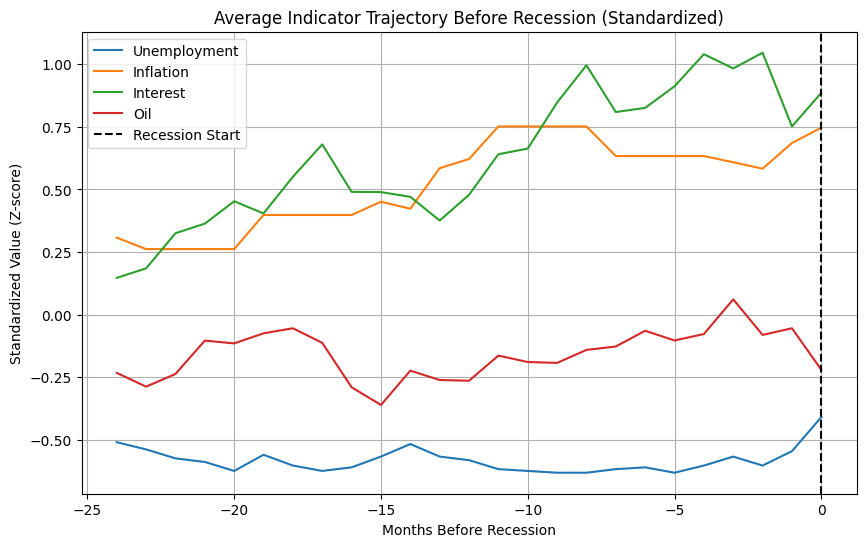

In [140]:
# normalize the dataframe
from sklearn.preprocessing import StandardScaler

scaled_df = economic_df.copy()

scaler = StandardScaler()

scaled_df[["Unemployment","Inflation","Interest", "Oil"]] = scaler.fit_transform(
    scaled_df[["Unemployment","Inflation","Interest", "Oil"]]
)

# trajectory function
traj = indicator_trajectory(
    scaled_df,
    indicators=["Unemployment","Inflation","Interest", "Oil"],
    months_before=24
)

# plot
plt.figure(figsize=(10,6))

for col in traj.columns:
    plt.plot(traj.index, traj[col], label=col)

plt.axvline(0, linestyle="--", color="black", label="Recession Start")

plt.xlabel("Months Before Recession")
plt.ylabel("Standardized Value (Z-score)")
plt.title("Average Indicator Trajectory Before Recession (Standardized)")

plt.legend()
plt.grid(True)

plt.show()


From this graph, we have learned that in average, both the inflation and interest rate has increased, while the unemployment doesn't show much difference.

### 2. Financial: SP500, VIX, Gold

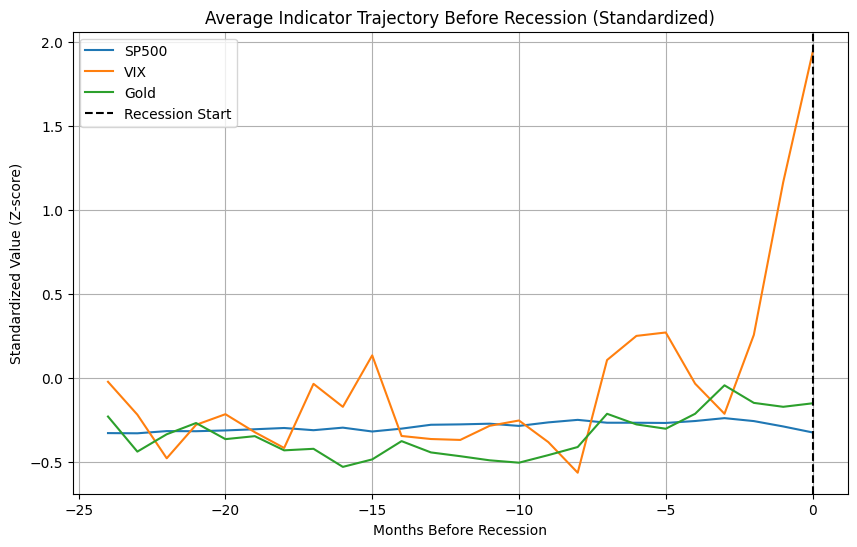

In [134]:
# normalize the dataframe
from sklearn.preprocessing import StandardScaler

scaled_df = financial_df.copy()

scaler = StandardScaler()

scaled_df[["SP500","VIX","Gold"]] = scaler.fit_transform(
    scaled_df[["SP500","VIX","Gold"]]
)

# trajectory function
traj = indicator_trajectory(
    scaled_df,
    indicators=["SP500","VIX","Gold"],
    months_before=24
)

# plot
plt.figure(figsize=(10,6))

for col in traj.columns:
    plt.plot(traj.index, traj[col], label=col)

plt.axvline(0, linestyle="--", color="black", label="Recession Start")

plt.xlabel("Months Before Recession")
plt.ylabel("Standardized Value (Z-score)")
plt.title("Average Indicator Trajectory Before Recession (Standardized)")

plt.legend()
plt.grid(True)

plt.show()


This line graph shows that VIX skyrocketed 3 months before each recession while S&P500 and Gold doesn't share much information.